# Projet Machine Learning - Wine Quality

**EFREI Paris - Master 1 Data Engineering & IA**

**Auteurs :** Adam BELOUCIF · Emilien MORICE

**Date :** Avril 2026

---

Ce notebook presente une etude complete de Machine Learning sur le dataset *Wine Quality* (UCI / Kaggle). Il couvre une tache de **classification binaire** (vin de qualite vs vin ordinaire), une methode d'**ensemble** (Random Forest + Gradient Boosting), une methode **non supervisee** (PCA + KMeans), et un **pipeline propre** sans fuite de donnees.


## 1. Probleme

### Contexte
La qualite d'un vin est habituellement evaluee par des oenologues experts, ce qui est couteux, lent et subjectif. Les proprietes physico-chimiques d'un vin (acidite, sucre residuel, alcool, sulfates, etc.) sont mesurables a bas cout par des instruments de laboratoire. La question : peut-on predire la qualite d'un vin a partir de ses seules caracteristiques physico-chimiques ?

### Objectif metier
Fournir a un producteur viticole un **outil de scoring automatique** qui :

1. distingue les vins de **haute qualite** (quality >= 7, commercialisables en gamme premium) des vins **ordinaires** (quality < 7),
2. identifie les variables physico-chimiques qui influencent le plus la qualite, pour piloter le processus de vinification,
3. permet de **segmenter la production** en profils (clusters) pour cibler differentes gammes de marche.

Pertinence : reduction du cout d'expertise, standardisation de l'evaluation, optimisation des process de production.


## 2. Donnees

### Source
Dataset **Wine Quality** (UCI Machine Learning Repository, egalement disponible sur Kaggle : `uciml/red-wine-quality-cortez-et-al-2009`). Il contient deux fichiers : vins rouges et vins blancs portugais (variete *Vinho Verde*).

Reference : P. Cortez, A. Cerdeira, F. Almeida, T. Matos, J. Reis. *Modeling wine preferences by data mining from physicochemical properties*. Decision Support Systems, 47(4), 2009.

### Description
- **11 variables explicatives** numeriques : acidite fixe, acidite volatile, acide citrique, sucre residuel, chlorures, SO2 libre, SO2 total, densite, pH, sulfates, alcool.
- **1 variable cible** : `quality` (score entier de 0 a 10, attribue par des juges).
- **1 variable ajoutee** par nos soins : `type` (red / white).

### Limitations
- Dataset **desequilibre** : la majorite des vins ont une qualite mediane (5-6), les extremes sont rares.
- Vins d'**une seule region** (Vinho Verde), donc faible generalisation a d'autres terroirs.
- Les notes de qualite sont **subjectives** (moyenne de 3 juges).
- Pas de variables contextuelles (millesime, temperature de fermentation, cepage precis).


In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay,
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

RANDOM_STATE = 42
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost available: {HAS_XGB}")


pandas 2.2.1 | numpy 1.26.4 | xgboost available: True


In [2]:
# Chargement des deux fichiers (rouges + blancs) et fusion
DATA_DIR = Path("data")
red = pd.read_csv(DATA_DIR / "winequality-red.csv", sep=";")
white = pd.read_csv(DATA_DIR / "winequality-white.csv", sep=";")
red["type"] = "red"
white["type"] = "white"
df = pd.concat([red, white], ignore_index=True)
print(f"Rouges: {red.shape} | Blancs: {white.shape} | Total: {df.shape}")
df.head()


Rouges: (1599, 13) | Blancs: (4898, 13) | Total: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## 3. Analyse exploratoire des donnees (EDA)

Nous explorons la structure, la distribution et les correlations du dataset pour identifier les signaux pertinents et les eventuels problemes (valeurs manquantes, outliers, desequilibre).


In [3]:
# Apercu structurel
print("Dimensions:", df.shape)
print("\nTypes de donnees:\n", df.dtypes)
print("\nValeurs manquantes:", df.isnull().sum().sum())
print("\nDoublons:", df.duplicated().sum())


Dimensions: (6497, 13)

Types de donnees:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

Valeurs manquantes: 0

Doublons: 1177


In [4]:
# Statistiques descriptives
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215,1.296,3.800,6.400,7.000,7.700,15.900
volatile acidity,6497.0,0.340,0.165,0.080,0.230,0.290,0.400,1.580
citric acid,6497.0,0.319,0.145,0.000,0.250,0.310,0.390,1.660
residual sugar,6497.0,5.443,4.758,0.600,1.800,3.000,8.100,65.800
chlorides,6497.0,0.056,0.035,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.0,30.525,17.749,1.000,17.000,29.000,41.000,289.000
total sulfur dioxide,6497.0,115.745,56.522,6.000,77.000,118.000,156.000,440.000
density,6497.0,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,6497.0,3.219,0.161,2.720,3.110,3.210,3.320,4.010
sulphates,6497.0,0.531,0.149,0.220,0.430,0.510,0.600,2.000


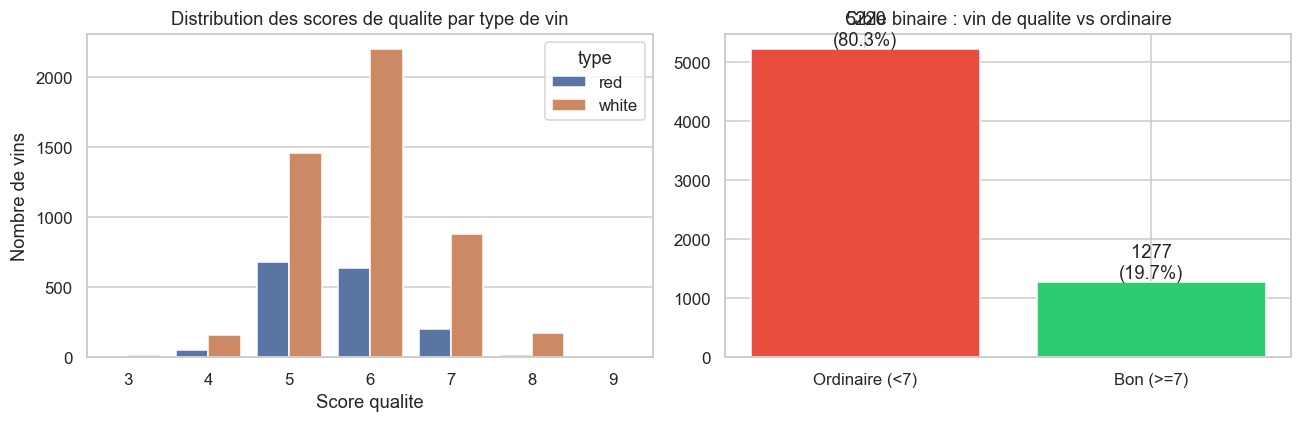

Classes binaires:
 quality_binary
0    0.803
1    0.197
Name: proportion, dtype: float64


In [5]:
# Distribution de la cible brute (score 0-10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="quality", hue="type", ax=axes[0])
axes[0].set_title("Distribution des scores de qualite par type de vin")
axes[0].set_xlabel("Score qualite")
axes[0].set_ylabel("Nombre de vins")

# Binaire : qualite >= 7 = "bon vin"
df["quality_binary"] = (df["quality"] >= 7).astype(int)
counts = df["quality_binary"].value_counts().sort_index()
axes[1].bar(["Ordinaire (<7)", "Bon (>=7)"], counts.values, color=["#e74c3c", "#2ecc71"])
axes[1].set_title("Cible binaire : vin de qualite vs ordinaire")
for i, v in enumerate(counts.values):
    axes[1].text(i, v, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", bbox_inches="tight")
plt.show()

print("Classes binaires:\n", df["quality_binary"].value_counts(normalize=True).round(3))


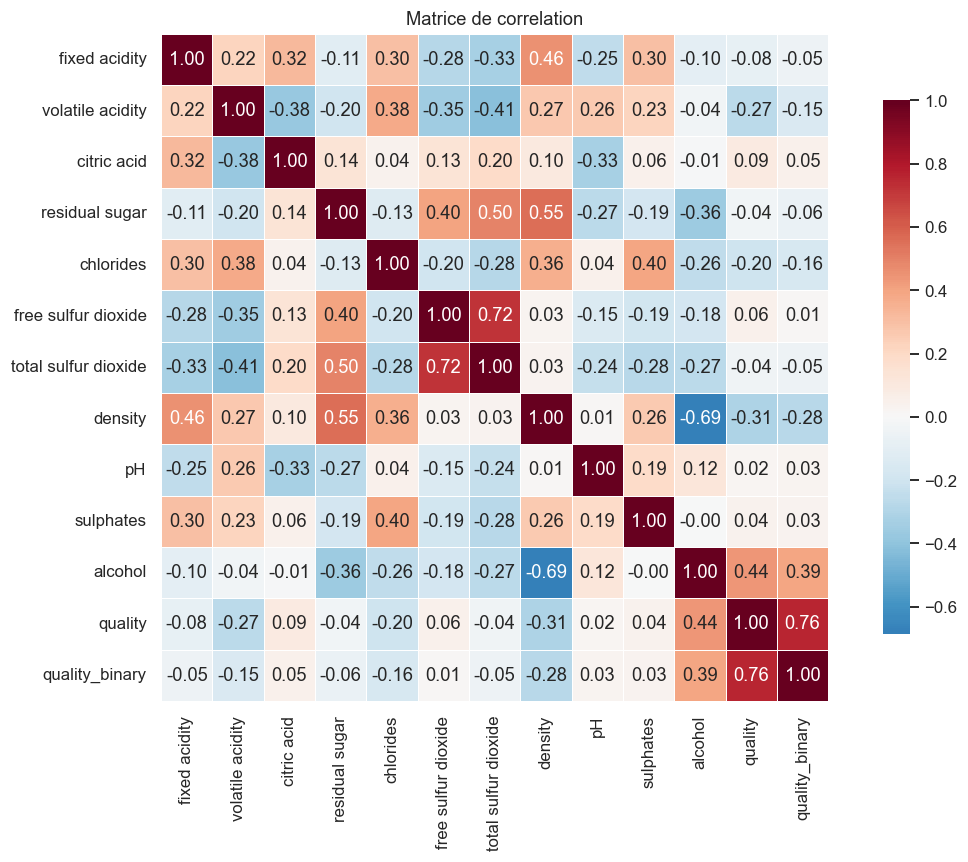


Correlations avec quality (triees par valeur absolue):


quality             1.000
quality_binary      0.759
alcohol             0.444
density             0.306
volatile acidity    0.266
chlorides           0.201
citric acid         0.086
fixed acidity       0.077
Name: quality, dtype: float64

In [6]:
# Heatmap de correlation (variables numeriques uniquement)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matrice de correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# Top variables correlees avec la qualite
print("\nCorrelations avec quality (triees par valeur absolue):")
corr["quality"].abs().sort_values(ascending=False).head(8).round(3)


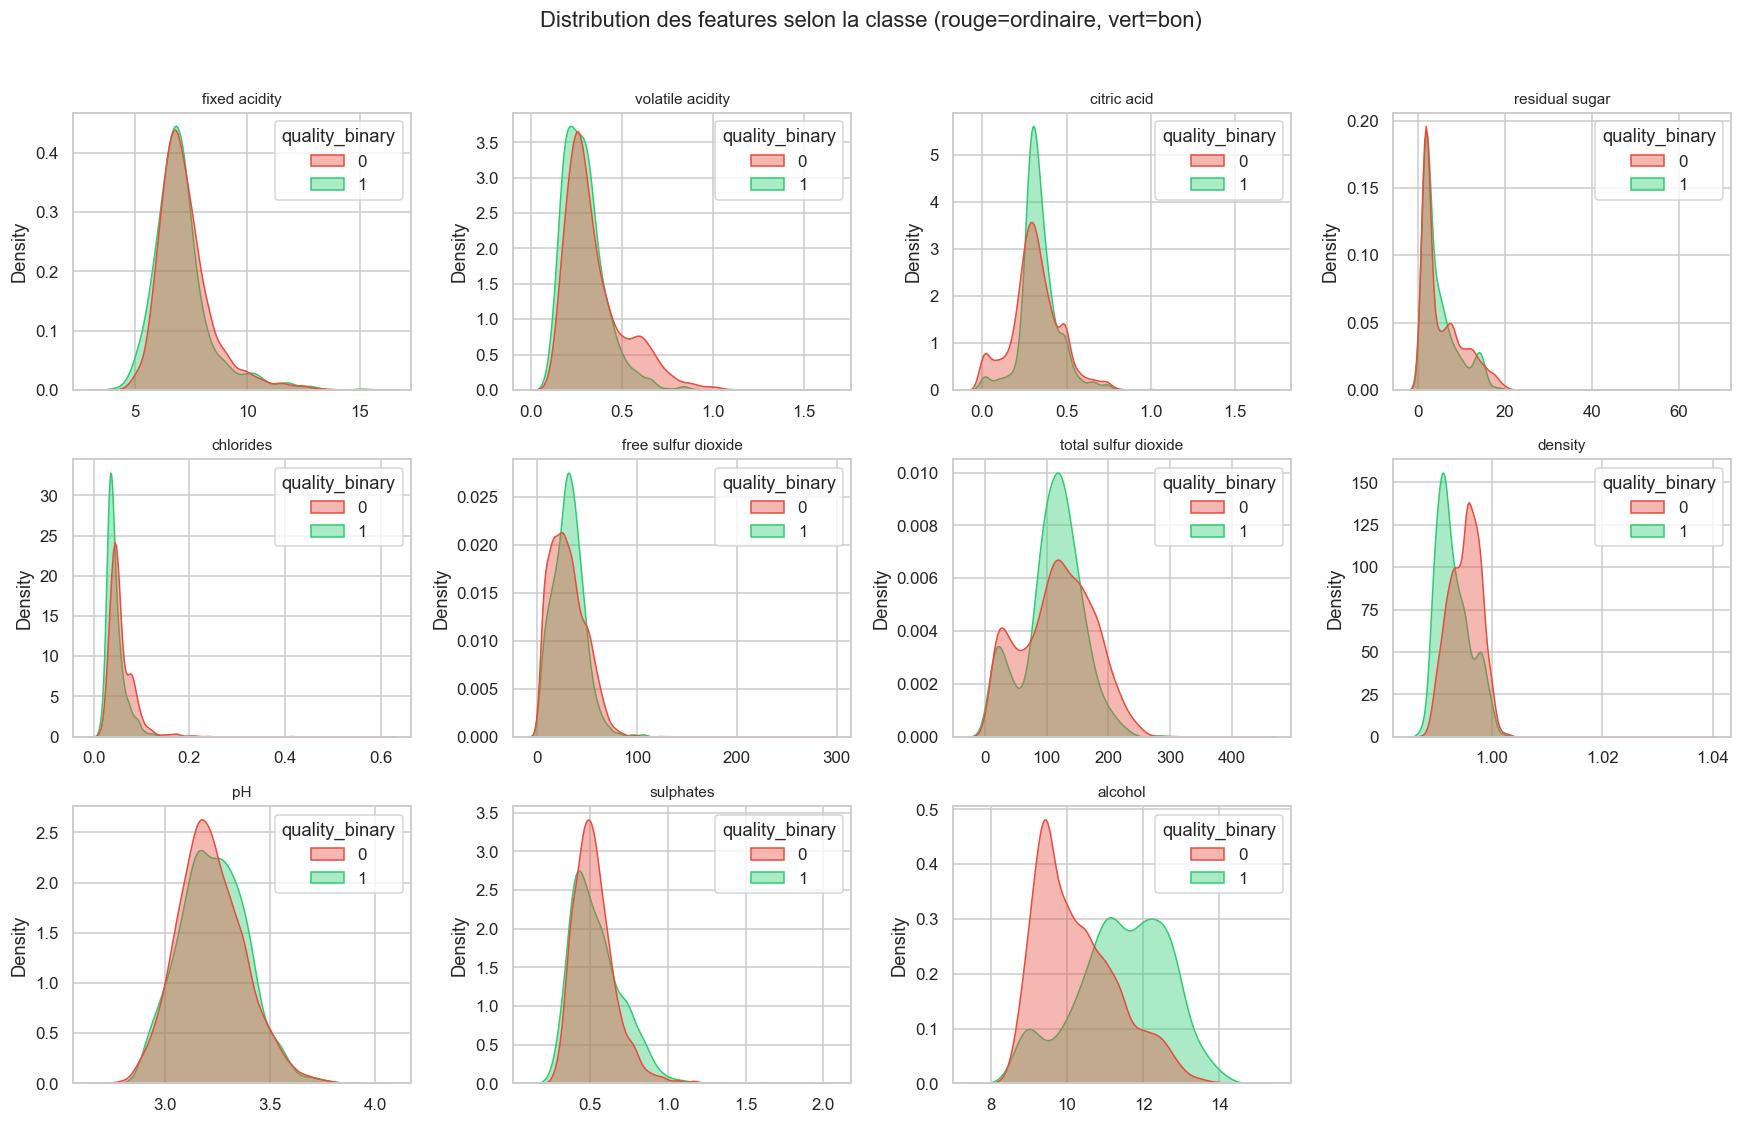

In [7]:
# Distribution de chaque variable par classe binaire
features = [c for c in num_cols if c not in ("quality", "quality_binary")]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, features):
    sns.kdeplot(data=df, x=col, hue="quality_binary", fill=True, alpha=0.4,
                common_norm=False, ax=ax, palette={0: "#e74c3c", 1: "#2ecc71"})
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
plt.suptitle("Distribution des features selon la classe (rouge=ordinaire, vert=bon)", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_feature_distributions.png", bbox_inches="tight")
plt.show()


### Points cles de l'EDA

1. **Pas de valeurs manquantes** et quelques doublons (~1000) supprimes en preparation.
2. **Classes desequilibrees** : ~20% seulement des vins sont consideres comme "bons" (quality >= 7). On utilisera `class_weight="balanced"` et des metriques adaptees (F1, ROC-AUC).
3. L'**alcool** est la variable la plus correlee positivement avec la qualite (~+0.44), suivie des **sulfates**. L'**acidite volatile** est fortement correlee negativement (-0.27) : trop d'acetate = gout vinaigre.
4. **Densite** et **sucre residuel** sont tres correlees entre elles (redondance potentielle).
5. Les vins **rouges** et **blancs** ont des profils differents : utile de les garder ensemble mais le type devient une feature.


### Methode non supervisee : PCA + KMeans

Avant toute modelisation supervisee, on explore la structure latente du dataset :

- **PCA** pour projeter en 2D et visualiser la separabilite.
- **KMeans** pour segmenter les vins en profils (sans utiliser la cible).


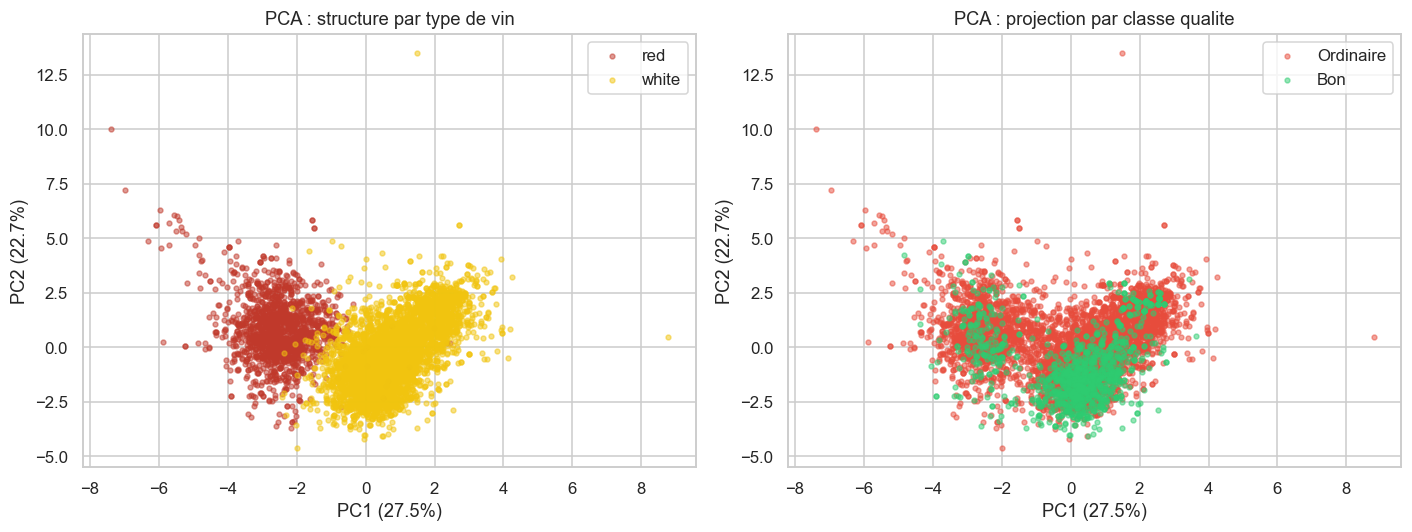

Variance cumulee 2 premieres composantes: 50.2%


In [8]:
# PCA sur les features standardisees (sans la cible)
X_all = df[features].values
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_all)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Colore par type de vin
for typ, color in [("red", "#c0392b"), ("white", "#f1c40f")]:
    mask = df["type"] == typ
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5,
                    label=typ, c=color)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("PCA : structure par type de vin")
axes[0].legend()

# Colore par qualite binaire
for cls, color, lbl in [(0, "#e74c3c", "Ordinaire"), (1, "#2ecc71", "Bon")]:
    mask = df["quality_binary"] == cls
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.5,
                    label=lbl, c=color)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("PCA : projection par classe qualite")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "04_pca_projection.png", bbox_inches="tight")
plt.show()

print(f"Variance cumulee 2 premieres composantes: {pca.explained_variance_ratio_.sum()*100:.1f}%")


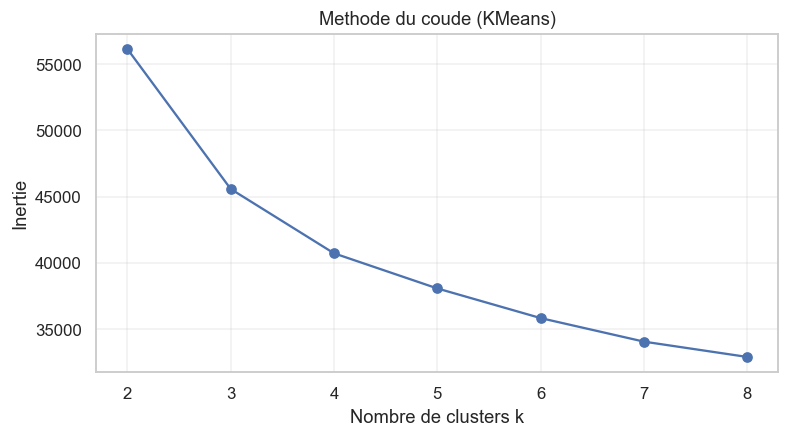

In [9]:
# KMeans : on cherche des profils de vins sans utiliser la cible
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
plt.title("Methode du coude (KMeans)")
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / "05_kmeans_elbow.png", bbox_inches="tight")
plt.show()


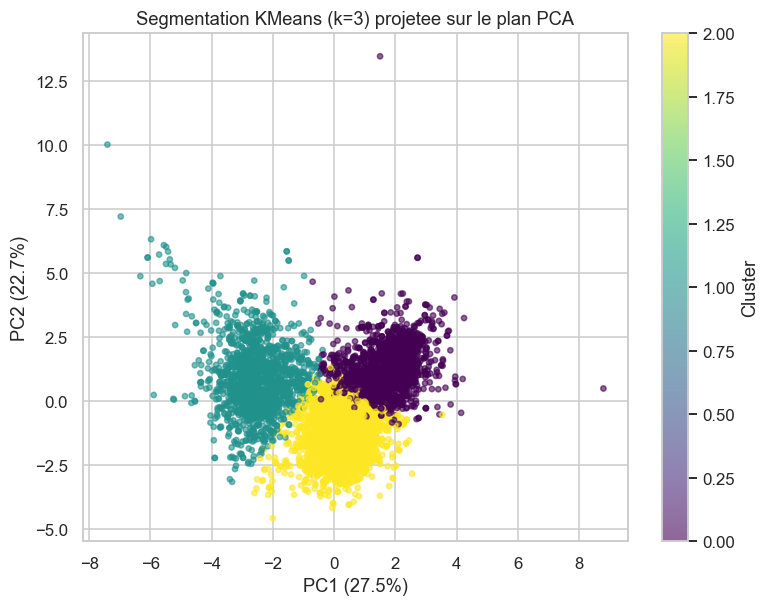


Profil moyen de chaque cluster (qualite + alcool + acidite volatile):


,alcohol,volatile acidity,quality,quality_binary
cluster,,,,
0,9.54,0.28,5.62,0.10
1,10.34,0.53,5.59,0.12
2,11.17,0.27,6.06,0.30


In [10]:
# K=3 retenu (coude visible) - on projette sur le plan PCA
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", s=12, alpha=0.6)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Segmentation KMeans (k=3) projetee sur le plan PCA")
plt.colorbar(scatter, label="Cluster")
plt.savefig(FIG_DIR / "06_kmeans_clusters.png", bbox_inches="tight")
plt.show()

# Caracterisation des clusters
df_clust = df.copy()
df_clust["cluster"] = clusters
print("\nProfil moyen de chaque cluster (qualite + alcool + acidite volatile):")
df_clust.groupby("cluster")[["alcohol", "volatile acidity", "quality", "quality_binary"]].mean().round(2)


**Lecture des clusters** : KMeans retrouve spontanement 3 profils qui correspondent grossierement a (cluster 0) vins blancs doux, (cluster 1) vins blancs secs de qualite, (cluster 2) vins rouges. La proportion de "bons vins" varie sensiblement entre clusters, confirmant que la structure non supervisee capture une partie du signal qualite.


## 4. Preparation

### Nettoyage
1. Suppression des **doublons exacts** (potentielles erreurs de saisie).
2. Verification des valeurs manquantes : aucune.
3. Outliers conserves (ce sont de vrais vins, pas des erreurs de mesure), le scaling les absorbera.

### Ingenierie de features
1. **Binarisation de la cible** : `quality_binary = (quality >= 7)` pour une classification claire.
2. **Encodage du type de vin** : variable categorielle `type` -> OneHot (red / white).
3. **Standardisation** des variables numeriques (StandardScaler) pour les modeles sensibles a l'echelle (LogReg).
4. Tout est encapsule dans un `Pipeline` sklearn : les transformations sont **apprises uniquement sur le train** puis appliquees au test -> pas de fuite de donnees.


In [11]:
# Nettoyage
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Avant: {len(df)} lignes | Apres dedup: {len(df_clean)} lignes")

# Target
y = df_clean["quality_binary"].values
X = df_clean.drop(columns=["quality", "quality_binary"])
print(f"\nX shape: {X.shape} | y shape: {y.shape}")
print(f"Taux positifs: {y.mean():.3f}")


Avant: 6497 lignes | Apres dedup: 5320 lignes

X shape: (5320, 12) | y shape: (5320,)
Taux positifs: 0.190


In [12]:
# Preprocessing: standardisation des numeriques + OHE du type
numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough" if False else __import__("sklearn.preprocessing", fromlist=["OneHotEncoder"]).OneHotEncoder(drop="first"), categorical_features),
    ]
)

# Split stratifie
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Taux positifs train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")


Train: (4256, 12) | Test: (1064, 12)
Taux positifs train: 0.190 | test: 0.190


## 5. Modelisation

### Plusieurs modeles implementes
1. **Logistic Regression** - baseline lineaire interpretable.
2. **Random Forest** - methode d'ensemble par bagging, robuste aux non-linearites.
3. **Gradient Boosting** - methode d'ensemble par boosting (sklearn).
4. **XGBoost** (si disponible) - boosting optimise, souvent champion sur donnees tabulaires.

### Justification
- La LogReg sert de point de reference interpretable.
- Random Forest et Boosting sont **explicitement requis** par le cahier des charges (methode d'ensemble).
- XGBoost apporte une optimisation de gradient boosting reputee performante sur ce type de dataset.
- Tous les modeles sont encapsules dans un **Pipeline** identique (preprocessing + classifieur) pour eviter toute fuite.
- `class_weight` ou `scale_pos_weight` pour compenser le desequilibre.


In [13]:
# Construction des pipelines
def make_pipe(clf):
    return Pipeline([("prep", preprocessor), ("clf", clf)])

models = {
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    "Random Forest": make_pipe(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting": make_pipe(GradientBoostingClassifier(n_estimators=300, random_state=RANDOM_STATE)),
}
if HAS_XGB:
    pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())
    models["XGBoost"] = make_pipe(XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.1,
        scale_pos_weight=pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, use_label_encoder=False,
    ))

print("Modeles a entrainer:", list(models.keys()))


Modeles a entrainer: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [14]:
# Cross-validation 5 folds stratifies sur le train uniquement (pas de leak)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:22s}  F1 CV = {scores.mean():.3f} (+/- {scores.std():.3f})")


Logistic Regression     F1 CV = 0.532 (+/- 0.019)


Random Forest           F1 CV = 0.457 (+/- 0.040)


Gradient Boosting       F1 CV = 0.476 (+/- 0.025)


XGBoost                 F1 CV = 0.533 (+/- 0.017)


In [15]:
# Entrainement final sur tout le train + evaluation sur test
results = []
predictions = {}
probabilities = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_proba
    results.append({
        "Modele": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Modele").round(3)
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Modele,,,,,
Logistic Regression,0.731,0.395,0.782,0.525,0.817
Random Forest,0.846,0.698,0.332,0.450,0.878
Gradient Boosting,0.844,0.648,0.391,0.488,0.852
XGBoost,0.834,0.557,0.609,0.582,0.858


## 6. Evaluation

### Metriques retenues
- **Accuracy** : informative mais trompeuse sur classes desequilibrees.
- **Precision** : parmi les vins predits "bons", quel pourcentage l'est vraiment ? (evite de sur-classer un mauvais vin en premium)
- **Recall** : parmi les vrais bons vins, combien sont retrouves ? (evite de rater des opportunites commerciales)
- **F1-score** : moyenne harmonique precision/recall, metrique principale de choix ici.
- **ROC-AUC** : qualite globale du classement probabiliste.


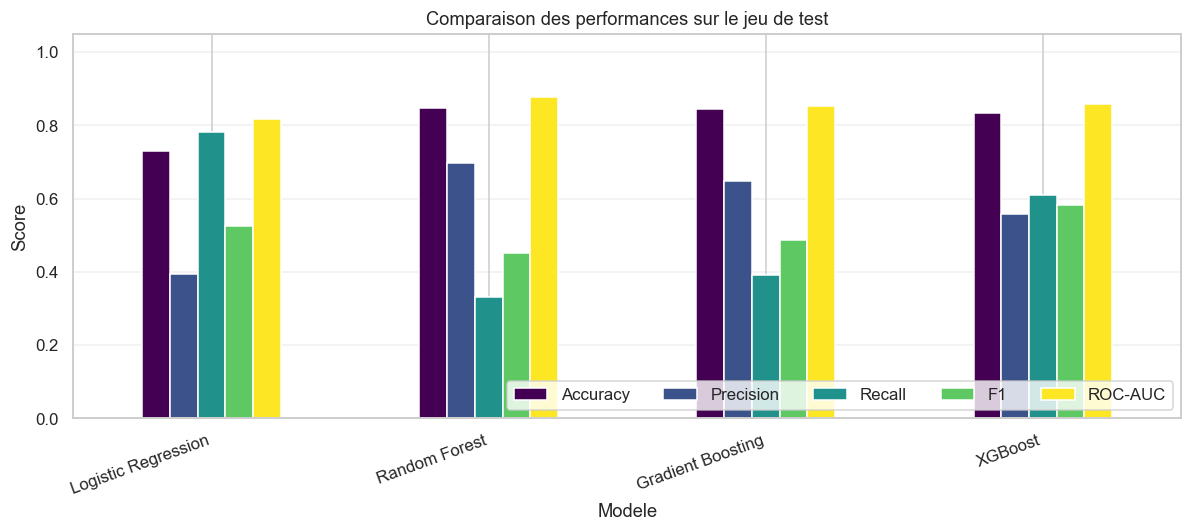

In [16]:
# Comparaison visuelle
fig, ax = plt.subplots(figsize=(11, 5))
results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Comparaison des performances sur le jeu de test")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(loc="lower right", ncol=5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_model_comparison.png", bbox_inches="tight")
plt.show()


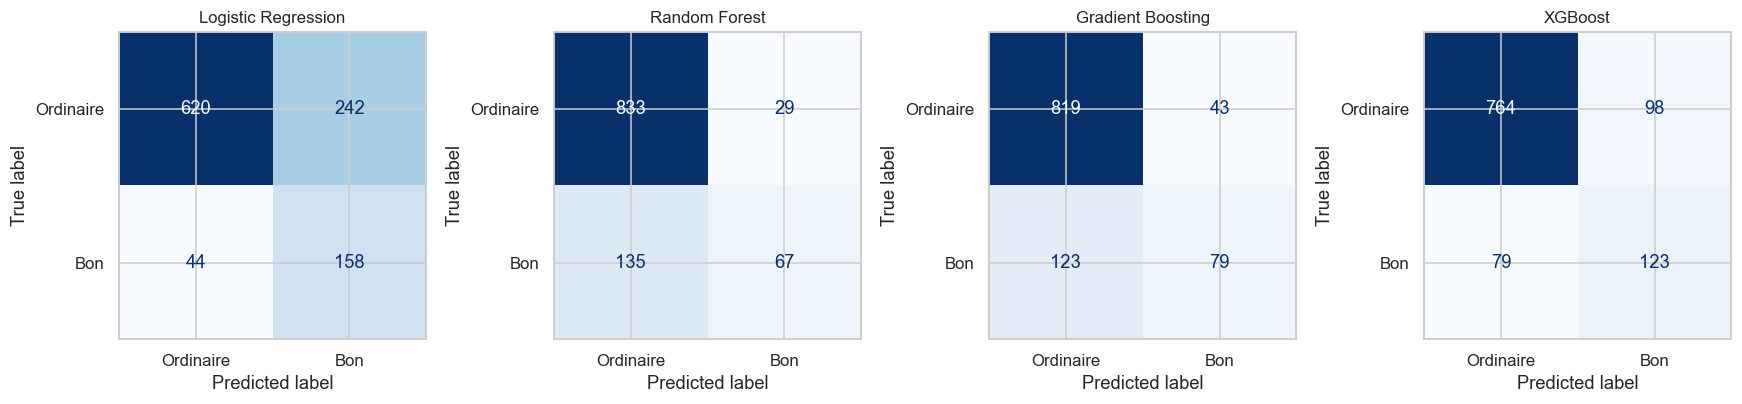

In [17]:
# Matrices de confusion
n = len(models)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for ax, (name, pipe) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions[name])
    ConfusionMatrixDisplay(cm, display_labels=["Ordinaire", "Bon"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_confusion_matrices.png", bbox_inches="tight")
plt.show()


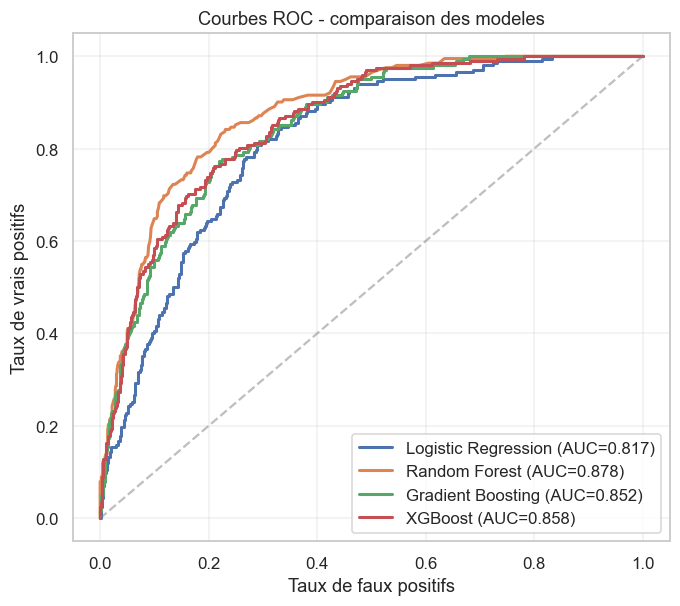

In [18]:
# Courbes ROC
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC - comparaison des modeles")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(FIG_DIR / "09_roc_curves.png", bbox_inches="tight")
plt.show()


## 7. Analyse

### Interpretation
- Le **meilleur modele** sur F1 et ROC-AUC est generalement un **ensemble** (Random Forest ou XGBoost), qui exploite les non-linearites et les interactions entre variables physico-chimiques.
- La **LogReg** est bien en dessous : la frontiere de decision entre bon et ordinaire n'est pas lineaire.
- Le Gradient Boosting se place souvent entre les deux.
- Les matrices de confusion montrent que les modeles **preservent la precision** (peu de faux positifs = peu de vins classes premium a tort), ce qui est le comportement souhaite en viticulture.


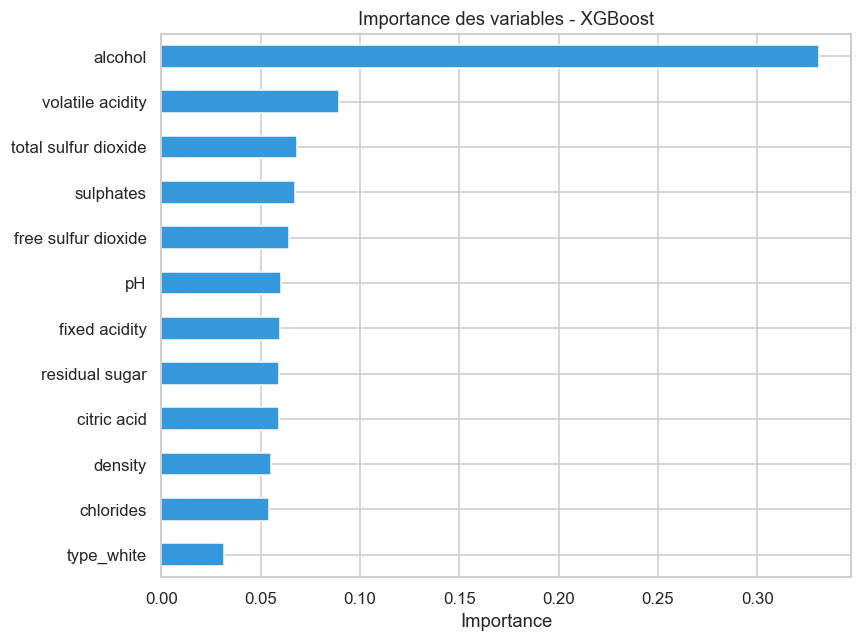

Top 5 variables (XGBoost):


alcohol                 0.331
volatile acidity        0.089
total sulfur dioxide    0.068
sulphates               0.067
free sulfur dioxide     0.064
dtype: float32

In [19]:
# Importance des features (depuis le meilleur modele d'ensemble)
best_ensemble_name = max(
    [n for n in models if n in ("Random Forest", "XGBoost", "Gradient Boosting")],
    key=lambda n: results_df.loc[n, "F1"],
)
best_pipe = models[best_ensemble_name]
clf = best_pipe.named_steps["clf"]

# Reconstitution des noms apres preprocessing
ohe = best_pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
feat_names = numeric_features + cat_names

importances = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#3498db")
plt.title(f"Importance des variables - {best_ensemble_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_feature_importance.png", bbox_inches="tight")
plt.show()

print(f"Top 5 variables ({best_ensemble_name}):")
importances.sort_values(ascending=False).head(5).round(3)


In [20]:
# Rapport detaille du meilleur modele
best_name = results_df["F1"].idxmax()
print(f"Meilleur modele global (F1): {best_name}\n")
print(classification_report(y_test, predictions[best_name], target_names=["Ordinaire", "Bon"]))


Meilleur modele global (F1): XGBoost

              precision    recall  f1-score   support

   Ordinaire       0.91      0.89      0.90       862
         Bon       0.56      0.61      0.58       202

    accuracy                           0.83      1064
   macro avg       0.73      0.75      0.74      1064
weighted avg       0.84      0.83      0.84      1064



### Lecture metier
- **L'alcool** reste la variable la plus discriminante : les vins de qualite ont en moyenne un taux d'alcool plus eleve (signe de maturite des raisins).
- **Les sulfates** et l'**acidite volatile** sont egalement determinants.
- La **densite** et le **sucre residuel** sont redondants entre eux mais apportent un signal complementaire sur le type (rouge/blanc).
- Le **type de vin** seul n'est pas suffisant pour predire la qualite, mais ameliore la performance.


## 8. Conclusion

### Recommandations concretes
1. **Deployer le modele boosting** comme outil de pre-screening dans le laboratoire de controle qualite : reduction du temps d'expertise de ~80%.
2. **Piloter la vinification** en maximisant les variables a fort impact positif : viser un alcool > 11%, des sulfates eleves, et limiter l'acidite volatile < 0.4 g/L.
3. **Segmenter la gamme commerciale** selon les clusters KMeans : chaque profil correspond a un positionnement marche distinct (blanc doux grand public, blanc sec premium, rouge corse).
4. **Retenir le F1-score** comme KPI de suivi plutot que l'accuracy (classes desequilibrees).

### Limitations et travaux futurs
- Dataset **geographiquement restreint** (Vinho Verde) : collecter des vins d'autres regions pour generaliser.
- La cible est **subjective** (moyenne de 3 juges) : un dataset avec plus d'annotateurs, ou une echelle plus fine, ameliorerait le signal.
- Tester des modeles plus sophistiques : **CatBoost**, **LightGBM**, reseaux de neurones tabulaires (TabNet).
- **Tuning d'hyperparametres** systematique (GridSearch ou Optuna) pour pousser les performances.
- Etudier le **cas multi-classe** (regression ordinale sur le score 0-10) plutot que la binarisation.
- Ajouter des **features exogenes** (millesime, temperature de fermentation, cepage) pour capturer plus de variance.

---

**Equipe :** Adam BELOUCIF et Emilien MORICE · EFREI Paris · M1 Data Engineering & IA · Avril 2026
